# Baselines for LSST Classification

- **B1**: Catch22 + RF (see `Baseline_first_model.ipynb`) — ~60% accuracy
- **B2**: MultiROCKET (aeon, no pre-training)
- **B3**: 1D-CNN from scratch (PyTorch)

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.data_loader import load_lsst_for_sklearn, stratified_train_val_split, SEED
from src.baselines import train_multirocket, train_cnn
from src.metrics import evaluate, plot_confusion_matrix, results_table

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [2]:
data = load_lsst_for_sklearn()
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
class_names = data["class_names"]
class_weights = data["class_weights"]
n_classes = data["n_classes"]

print(f"Train: {X_train.shape}, Test: {X_test.shape}, Classes: {n_classes}")

Train: (2459, 6, 36), Test: (2466, 6, 36), Classes: 14


## B2: MultiROCKET

In [3]:
rocket = train_multirocket(X_train, y_train)
y_pred_rocket = rocket.predict(X_test)
metrics_rocket = evaluate(y_test, y_pred_rocket, class_names, "MultiROCKET")

=== MultiROCKET ===
Accuracy:    0.6375
Weighted F1: 0.6039
Macro F1:    0.4615
              precision    recall  f1-score   support

          15       0.63      0.45      0.53       124
          16       0.93      0.93      0.93       270
          42       0.43      0.43      0.43       382
          52       0.00      0.00      0.00        63
          53       1.00      0.57      0.73         7
           6       0.57      0.11      0.19        35
          62       0.25      0.15      0.19       153
          64       0.00      0.00      0.00        24
          65       0.72      0.85      0.78       313
          67       0.21      0.04      0.07        68
          88       0.94      0.84      0.89       121
          90       0.60      0.81      0.69       777
          92       0.92      0.88      0.90        77
          95       0.50      0.08      0.13        52

    accuracy                           0.64      2466
   macro avg       0.55      0.44      0.46      2466


/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

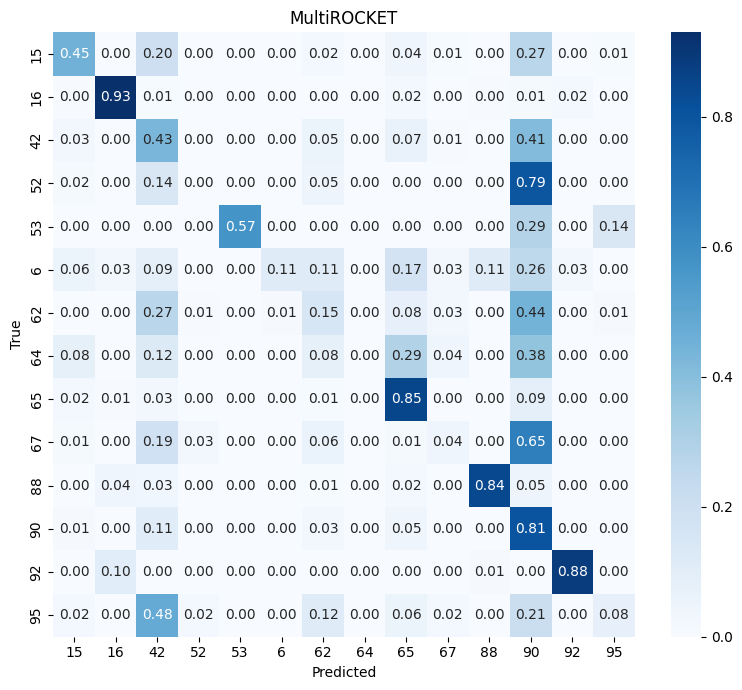

In [4]:
fig, ax = plot_confusion_matrix(y_test, y_pred_rocket, class_names, "MultiROCKET")
plt.show()

## B3: 1D-CNN from scratch

In [5]:
# Stratified train/val split for early stopping
X_tr, X_val, y_tr, y_val = stratified_train_val_split(X_train, y_train)
print(f"Train: {X_tr.shape}, Val: {X_val.shape}")

Train: (1967, 6, 36), Val: (492, 6, 36)


In [6]:
cnn_model, cnn_history = train_cnn(
    X_tr, y_tr, X_val, y_val, class_weights,
    n_channels=6, seq_len=36, n_classes=n_classes,
    epochs=100, lr=1e-3, batch_size=128, patience=15,
    device=device,
)

Epoch 10/100 — train_loss=1.8930  val_loss=1.9992  val_acc=0.1992
Epoch 20/100 — train_loss=1.5778  val_loss=2.0350  val_acc=0.2297
Epoch 30/100 — train_loss=1.4310  val_loss=1.6882  val_acc=0.2561
Epoch 40/100 — train_loss=1.2977  val_loss=1.6954  val_acc=0.2744
Epoch 50/100 — train_loss=1.1915  val_loss=1.5991  val_acc=0.3049
Epoch 60/100 — train_loss=1.1543  val_loss=1.4955  val_acc=0.4187
Epoch 70/100 — train_loss=1.0847  val_loss=1.4508  val_acc=0.3801
Epoch 80/100 — train_loss=1.0799  val_loss=1.5780  val_acc=0.3374
Epoch 90/100 — train_loss=1.0266  val_loss=1.4746  val_acc=0.3577
Epoch 100/100 — train_loss=1.0475  val_loss=1.6723  val_acc=0.3537


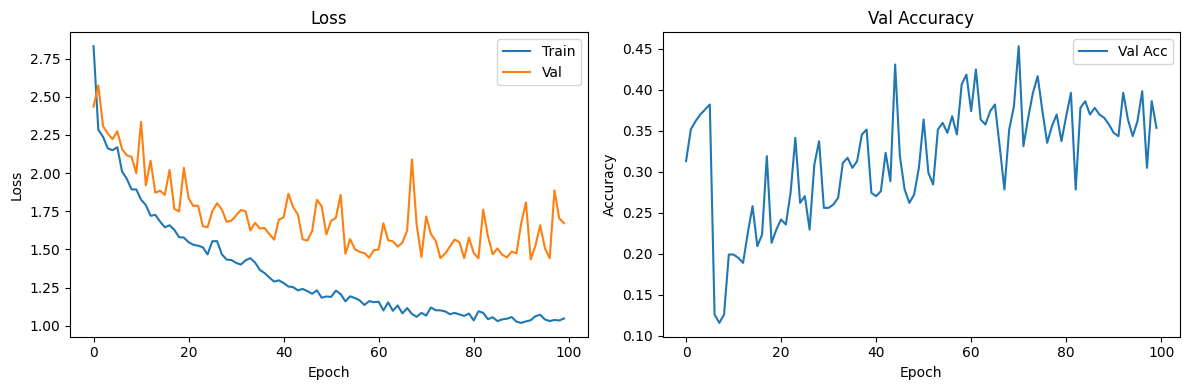

In [7]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(cnn_history["train_loss"], label="Train")
ax1.plot(cnn_history["val_loss"], label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.set_title("Loss")
ax2.plot(cnn_history["val_acc"], label="Val Acc")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.legend(); ax2.set_title("Val Accuracy")
plt.tight_layout(); plt.show()

In [8]:
# Evaluate CNN on test set
cnn_model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)
with torch.no_grad():
    y_pred_cnn = cnn_model(X_test_t).argmax(1).cpu().numpy()

metrics_cnn = evaluate(y_test, y_pred_cnn, class_names, "1D-CNN")

=== 1D-CNN ===
Accuracy:    0.3861
Weighted F1: 0.4246
Macro F1:    0.4604
              precision    recall  f1-score   support

          15       0.51      0.61      0.55       124
          16       0.91      0.72      0.80       270
          42       0.51      0.10      0.16       382
          52       0.05      0.49      0.08        63
          53       1.00      1.00      1.00         7
           6       0.60      0.34      0.44        35
          62       0.38      0.12      0.18       153
          64       0.05      0.29      0.09        24
          65       0.54      0.51      0.53       313
          67       0.11      0.43      0.17        68
          88       0.86      0.74      0.79       121
          90       0.60      0.26      0.36       777
          92       0.93      0.92      0.93        77
          95       0.34      0.38      0.36        52

    accuracy                           0.39      2466
   macro avg       0.53      0.49      0.46      2466
weigh

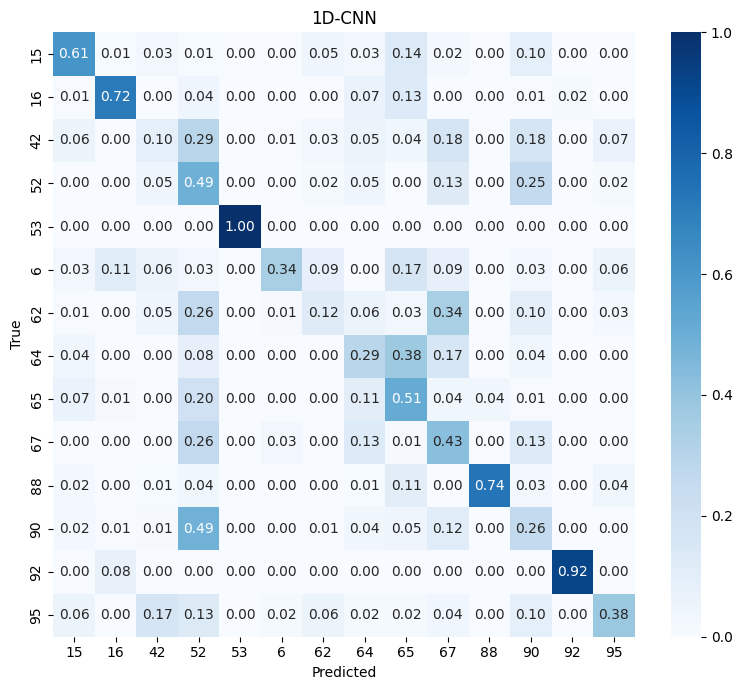

In [9]:
fig, ax = plot_confusion_matrix(y_test, y_pred_cnn, class_names, "1D-CNN")
plt.show()

## Summary

In [10]:
all_results = {
    "Catch22 + RF (B1)": dict(accuracy=0.60, weighted_f1=0.54, macro_f1=0.31),  # from notebook 1
    "MultiROCKET (B2)": metrics_rocket,
    "1D-CNN (B3)": metrics_cnn,
}
results_table(all_results)

Model                               Acc     W-F1     M-F1
---------------------------------------------------------
Catch22 + RF (B1)                0.6000   0.5400   0.3100
MultiROCKET (B2)                 0.6375   0.6039   0.4615
1D-CNN (B3)                      0.3861   0.4246   0.4604
